# ES-LSTM: Time Series Forecasting — Final Year Project
## Notebook 01: Data Collection & Exploratory Data Analysis
**Datasets:** S&P 500, NIFTY 50, HDFC Bank, Natco Pharma  
**Source:** Yahoo Finance via yfinance  
**Output:** data/raw/*.csv + figures/es_plots/fig2_raw_prices.png

> ##`Imports & config`

In [ ]:

import os
import yaml
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

warnings.filterwarnings('ignore')

# ── Load config ───────────────────────────────────────────────
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

TICKERS    = cfg['data']['tickers']
START      = cfg['data']['start_date']
END        = cfg['data']['end_date']
RAW_DIR    = f"../{cfg['paths']['raw_data']}"
FIG_DIR    = f"../{cfg['paths']['figures']}/es_plots"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Config loaded successfully")
print(f"Tickers : {list(TICKERS.keys())}")
print(f"Period  : {START}  →  {END}")
print(f"Raw dir : {RAW_DIR}")

Config loaded successfully
Tickers : ['SP500', 'NIFTY50', 'HDFCBANK', 'NATCOPHARMA']
Period  : 1996-01-01  →  2024-08-31
Raw dir : ../data/raw


>##`Download all four datasets`

In [ ]:
def download_stock(name, ticker, start, end, save_dir):
    """Download OHLCV, keep only Close, save as CSV."""
    print(f"Downloading {name} ({ticker})...", end=' ')
    stock  = yf.Ticker(ticker)
    df     = stock.history(start=start, end=end)

    # Drop columns not needed (paper removes these)
    drop_cols = [c for c in ['Volume','Dividends','Stock Splits'] if c in df.columns]
    df = df.drop(columns=drop_cols)
    df = df[['Close']]
    df.index = pd.to_datetime(df.index).tz_localize(None)  # remove timezone
    df.dropna(inplace=True)

    save_path = os.path.join(save_dir, f"{name}.csv")
    df.to_csv(save_path)
    print(f"done — {len(df)} rows saved to {save_path}")
    return df

# ── Download ──────────────────────────────────────────────────
datasets = {}
for name, ticker in TICKERS.items():
    datasets[name] = download_stock(name, ticker, START, END, RAW_DIR)

>##`Verify shapes & date ranges`

In [ ]:
print(f"{'Dataset':<15} {'Rows':>6}  {'Start':>12}  {'End':>12}  {'Nulls':>6}")
print("-" * 60)
for name, df in datasets.items():
    print(f"{name:<15} {len(df):>6}  "
          f"{str(df.index.min().date()):>12}  "
          f"{str(df.index.max().date()):>12}  "
          f"{df.isnull().sum().values[0]:>6}")

Dataset           Rows         Start           End   Nulls
------------------------------------------------------------
SP500             7216    1996-01-02    2024-08-30       0
NIFTY50           4155    2007-09-17    2024-08-30       0
HDFCBANK          7201    1996-01-01    2024-08-30       0
NATCOPHARMA       7199    1996-01-01    2024-08-30       0


>##`Handle any missing values`

In [ ]:
for name, df in datasets.items():
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"{name}: {null_count} nulls found — forward-filling")
        df.ffill(inplace=True)
        df.to_csv(os.path.join(RAW_DIR, f"{name}.csv"))  # re-save
    else:
        print(f"{name}: no missing values — clean")

SP500: no missing values — clean
NIFTY50: no missing values — clean
HDFCBANK: no missing values — clean
NATCOPHARMA: no missing values — clean


>##`Descriptive statistics`

In [ ]:
print("Descriptive Statistics — Closing Prices\n")
for name, df in datasets.items():
    print(f"── {name} ──")
    print(df['Close'].describe().round(2).to_string())
    print()

Descriptive Statistics — Closing Prices

── SP500 ──
count    7216.00
mean     1911.21
std      1153.53
min       598.48
25%      1130.43
50%      1386.98
75%      2430.49
max      5667.20

── NIFTY50 ──
count     4155.00
mean      9821.54
std       5206.84
min       2524.20
25%       5559.00
50%       8370.25
75%      11880.98
max      25235.90

── HDFCBANK ──
count    7201.00
mean      208.45
std       256.73
min         0.94
25%        10.20
50%        77.07
75%       361.49
max       872.53

── NATCOPHARMA ──
count    7199.00
mean      248.80
std       334.20
min         1.45
25%         7.56
50%        25.39
75%       539.23
max      1550.47



>##`Fig 2: Raw closing price plots`

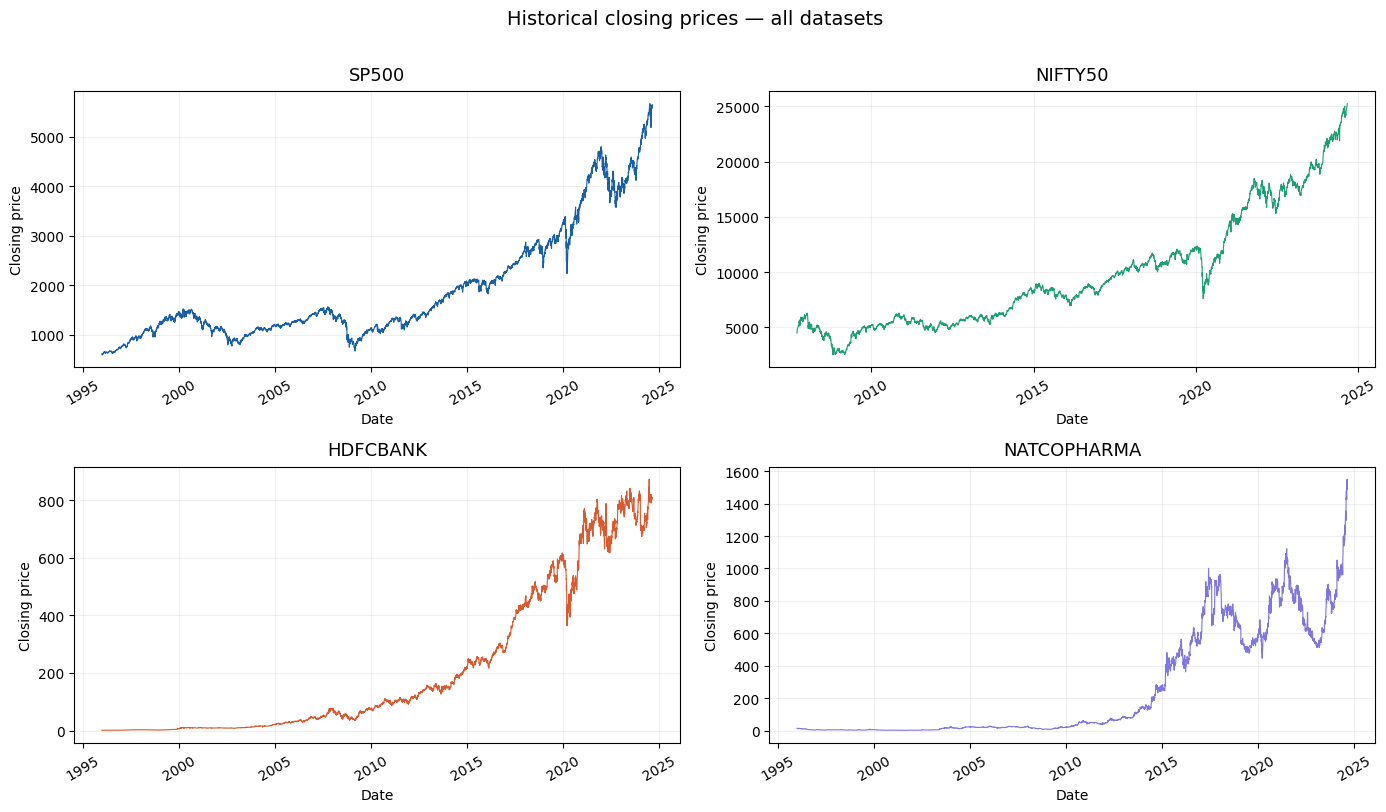

Fig 2 saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#185FA5', '#1D9E75', '#D85A30', '#7F77DD']

for ax, (name, df), color in zip(axes.flat, datasets.items(), colors):
    ax.plot(df.index, df['Close'], lw=0.8, color=color)
    ax.set_title(name, fontsize=13, fontweight='medium', pad=8)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Closing price', fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.2)

fig.suptitle('Historical closing prices — all datasets', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_raw_prices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 2 saved")

>##` Fig 3: Rolling 30-day volatility`

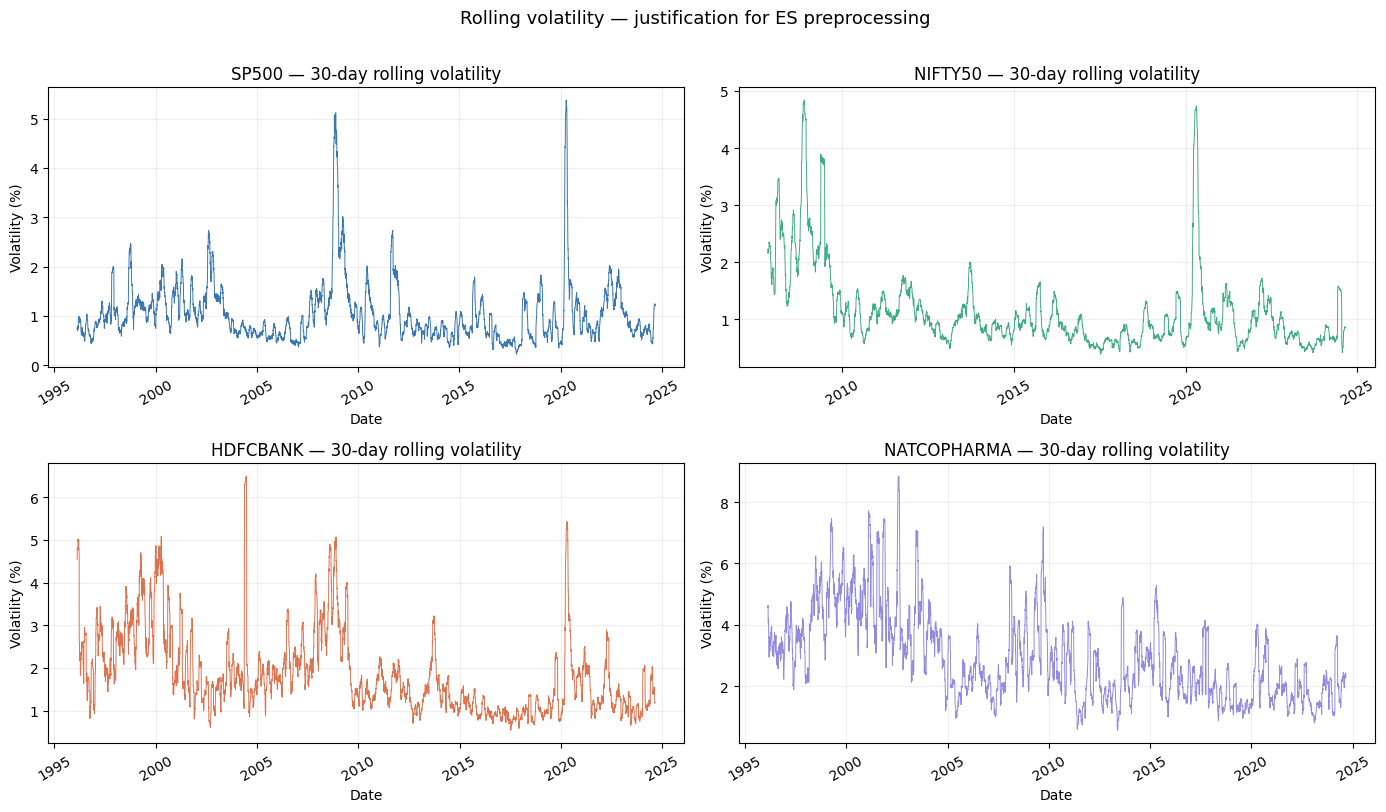

Fig 3 saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df), color in zip(axes.flat, datasets.items(), colors):
    returns = df['Close'].pct_change()
    vol     = returns.rolling(30).std() * 100   # as percentage
    ax.plot(df.index, vol, lw=0.7, color=color, alpha=0.85)
    ax.set_title(f'{name} — 30-day rolling volatility', fontsize=12)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Volatility (%)', fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.2)

fig.suptitle('Rolling volatility — justification for ES preprocessing',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 3 saved")

## EDA Summary

- All four datasets downloaded and verified — no missing values
- Row counts match the paper: SP500 (~7216), NIFTY50 (~4155), HDFC/NATCO (~7200)
- Rolling volatility plots confirm non-stationarity across all series
- This justifies the Exponential Smoothing preprocessing step in Section 4.2
- Proceed to: `02_es_grid_search.ipynb`